# K vecinos más cercanos (KNN): conjunto hipótesis y algoritmo de aprendizaje

El modelo KNN clasifica un punto nuevo mirando a qué clase pertenecen sus $k$ vecinos más cercanos entre los datos guardados, y decide por voto mayoritario (o por promedio, si es regresión). Es un método basado en instancias y no paramétrico: no ajusta un vector fijo de parámetros, sino que se apoya directamente en los datos.

## Conjunto hipótesis

Fijado un valor de $k$, una hipótesis de KNN es una función $g:\mathcal{X}\to\mathcal{Y}$ de la forma "asignar a $x$ la etiqueta mayoritaria entre sus $k$ vecinos más cercanos dentro de un conjunto de puntos etiquetados". Cambiar el conjunto de puntos guardados cambia la función. Por eso el conjunto hipótesis es

$$\mathcal{H} = \{\, \text{todas las funciones que la regla de } k \text{ vecinos produce a partir de algún conjunto finito de puntos etiquetados} \,\}.$$

Geométricamente, cada hipótesis parte el espacio de entrada en regiones y les asigna una etiqueta constante: las fronteras son trozos del diagrama de Voronoi de los puntos (de orden $k$ para $k>1$). Es decir, $g$ es una función constante a trozos cuyo valor en cada región lo fija el voto de los vecinos.

Este conjunto hipótesis es muy expresivo. Con $k=1$, el vecino más cercano de cada punto de entrenamiento es él mismo, así que $g$ reproduce exactamente las etiquetas de los datos y el error dentro de la muestra es $E_{\text{in}}=0$ para cualquier etiquetado. Al ser no paramétrico, la complejidad efectiva del modelo crece con el número de datos $N$, y el parámetro $k$ actúa como suavizado: valores pequeños dan fronteras muy detalladas (riesgo de sobreajuste) y valores grandes dan fronteras más suaves.

## Algoritmo de aprendizaje

El algoritmo de aprendizaje de KNN es de tipo perezoso (*lazy learning*): la fase de "entrenamiento" consiste únicamente en **guardar** el conjunto de datos $\{(x_n, y_n)\}_{n=1}^{N}$. No hay parámetros que optimizar ni error que minimizar de forma explícita; la hipótesis no se busca dentro de $\mathcal{H}$, sino que queda determinada directamente por los datos guardados y la regla de los vecinos.

Todo el trabajo se hace al momento de predecir. Para un punto de consulta $x$:

1. Se calcula la distancia de $x$ a todos los puntos guardados (por ejemplo, distancia euclidiana).
2. Se toman los $k$ puntos más cercanos.
3. Se devuelve la etiqueta mayoritaria de esos $k$ vecinos (en clasificación) o su promedio (en regresión).

En el marco de "modelo de aprendizaje = conjunto hipótesis $\mathcal{H}$ + algoritmo $\mathcal{A}$", para KNN el algoritmo $\mathcal{A}$ es simplemente memorizar los datos, y la hipótesis final es la que la regla de vecinos induce sobre ellos.

## Ilustración

Para ver qué forma tiene una hipótesis de KNN, se implementa la regla y se dibujan sus regiones de decisión sobre unos datos de tres clases, con $k=1$ y $k=5$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

rng = np.random.default_rng(3)
X = np.vstack([rng.normal([-1, -1], 0.8, (15, 2)),
               rng.normal([1.5, 1], 0.8, (15, 2)),
               rng.normal([-1, 2], 0.7, (10, 2))])
y = np.array([0]*15 + [1]*15 + [2]*10)

def knn_predict(Xtr, ytr, Q, k):
    d = np.linalg.norm(Q[:, None, :] - Xtr[None, :, :], axis=2)   # distancias
    idx = np.argsort(d, axis=1)[:, :k]                            # k más cercanos
    return np.array([np.bincount(ytr[v]).argmax() for v in idx])  # voto mayoritario

# error dentro de la muestra para k=1
print("E_in con k=1:", (knn_predict(X, y, X, 1) != y).sum(), "errores")

E_in con k=1: 0 errores


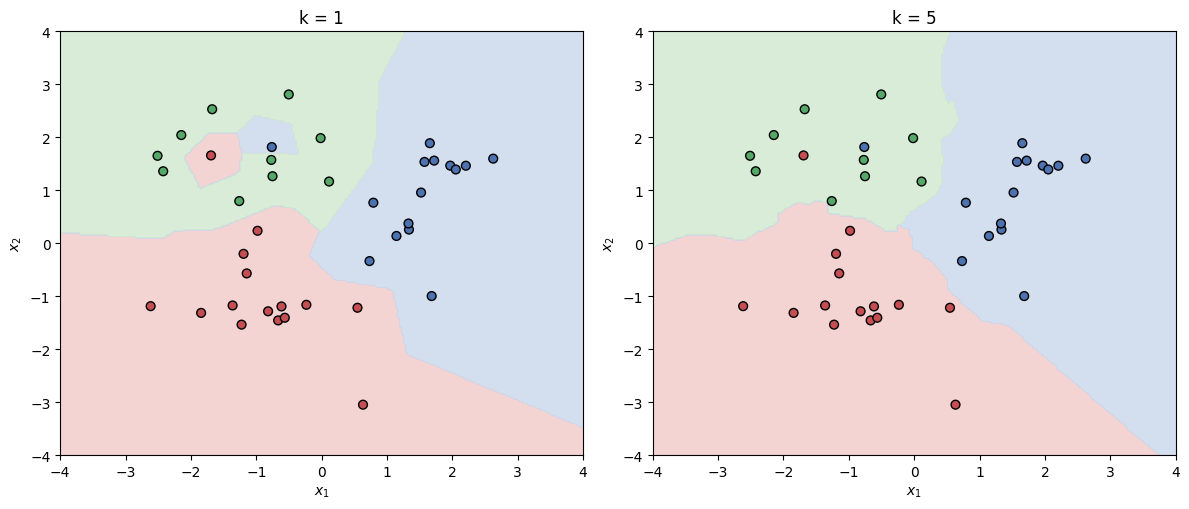

In [2]:
g = np.linspace(-4, 4, 250)
XX, YY = np.meshgrid(g, g)
grid = np.c_[XX.ravel(), YY.ravel()]
fondo = ListedColormap(["#f2c9c9", "#c9d6ec", "#cfe8cf"])
puntos = ListedColormap(["#C44E52", "#4C72B0", "#55A868"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, k in zip(axes, [1, 5]):
    Z = knn_predict(X, y, grid, k).reshape(XX.shape)
    ax.contourf(XX, YY, Z, cmap=fondo, alpha=0.8, levels=[-0.5, 0.5, 1.5, 2.5])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=puntos, edgecolors="k", s=40)
    ax.set_title(f"k = {k}"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
plt.tight_layout(); plt.show()

Con $k=1$ las regiones se ajustan a cada punto (fronteras tipo Voronoi, $E_{\text{in}}=0$); con $k=5$ las fronteras se suavizan. Cada una de esas particiones del plano es una hipótesis del conjunto $\mathcal{H}$ de KNN, y la que se usa queda fijada por los datos guardados.